# Improved Weighted CNN

- Keep the baseline `SimpleCNN` architecture
- Keep `F2` for checkpoint selection
- Use a softer `pos_weight` than the raw class ratio
- Tune the threshold more carefully on the validation set
- Add light regularization, LR scheduling, and early stopping


### 1. Import libraries

In [1]:
import sys
import os
import copy
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
)

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch

os.chdir(ROOT)
print(Path.cwd())


/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning


### 2. Use CUDA else MPS

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')


Using device: mps


### 3. Data, softened class weighting, and optimizer

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus = (train_df['label'] == 0).sum()

raw_pos_weight = num_nevus / num_melanoma
soft_pos_weight = min(raw_pos_weight, 5.0)
pos_weight = torch.tensor([soft_pos_weight], dtype=torch.float32).to(device)

print(f'Raw class-ratio pos_weight: {raw_pos_weight:.4f}')
print(f'Using softened pos_weight: {soft_pos_weight:.4f}')

model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

model_save_path = os.path.abspath('models/cnn_baseline_weighted_improved.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)


Raw class-ratio pos_weight: 8.1117
Using softened pos_weight: 5.0000


### 4. Train model with validation F2 checkpointing

In [4]:
num_epochs = 30
early_stopping_patience = 6

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f2s = []
val_f2s = []
learning_rates = []

best_val_f2 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_model_state = None

for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]['lr']

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)
    scheduler.step(val_metrics['f2'])

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])
    learning_rates.append(current_lr)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, model_save_path)
        print(f'Saved best model at epoch {best_epoch}')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print(f'Early stopping triggered at epoch {epoch + 1}')
        break

print(f'Best validation F2: {best_val_f2:.4f} at epoch {best_epoch}')

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch [1/30] | LR: 0.001000 | Train Loss: 0.8738, Train Acc: 0.7461, Train F2: 0.3338 | Val Loss: 0.8024, Val Acc: 0.6764, Val F2: 0.4657
Saved best model at epoch 1


Epoch [2/30] | LR: 0.001000 | Train Loss: 0.7520, Train Acc: 0.7615, Train F2: 0.4871 | Val Loss: 0.7911, Val Acc: 0.6215, Val F2: 0.5167
Saved best model at epoch 2


Epoch [3/30] | LR: 0.001000 | Train Loss: 0.7497, Train Acc: 0.7445, Train F2: 0.4937 | Val Loss: 0.8665, Val Acc: 0.5064, Val F2: 0.5160


Epoch [4/30] | LR: 0.001000 | Train Loss: 0.7692, Train Acc: 0.7493, Train F2: 0.5033 | Val Loss: 0.7629, Val Acc: 0.7322, Val F2: 0.5420
Saved best model at epoch 4


Epoch [5/30] | LR: 0.001000 | Train Loss: 0.7261, Train Acc: 0.7551, Train F2: 0.5380 | Val Loss: 0.8254, Val Acc: 0.7075, Val F2: 0.5445
Saved best model at epoch 5


...

Epoch [17/30] | LR: 0.000500 | Train Loss: 0.5683, Train Acc: 0.8090, Train F2: 0.6305 | Val Loss: 0.6653, Val Acc: 0.7683, Val F2: 0.5705


Epoch [18/30] | LR: 0.000500 | Train Loss: 0.5668, Train Acc: 0.8147, Train F2: 0.6248 | Val Loss: 0.7148, Val Acc: 0.7456, Val F2: 0.5879


Epoch [19/30] | LR: 0.000500 | Train Loss: 0.5685, Train Acc: 0.8119, Train F2: 0.6365 | Val Loss: 0.7175, Val Acc: 0.7589, Val F2: 0.5882


Epoch [20/30] | LR: 0.000250 | Train Loss: 0.5485, Train Acc: 0.8169, Train F2: 0.6398 | Val Loss: 0.6805, Val Acc: 0.7703, Val F2: 0.5846


Epoch [21/30] | LR: 0.000250 | Train Loss: 0.5346, Train Acc: 0.8262, Train F2: 0.6533 | Val Loss: 0.6860, Val Acc: 0.7624, Val F2: 0.5686
Early stopping triggered at epoch 21
Best validation F2: 0.5954 at epoch 15


### 5. Plot curves

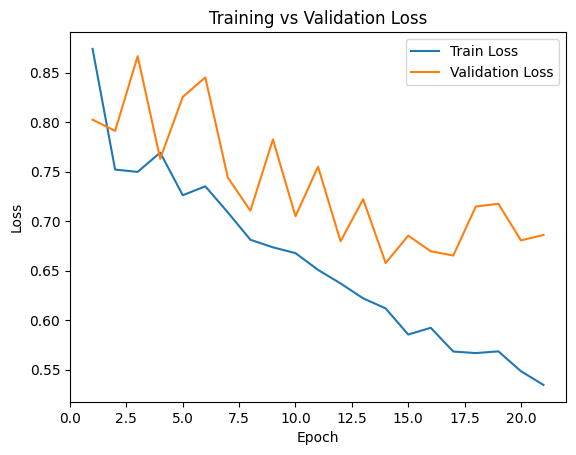

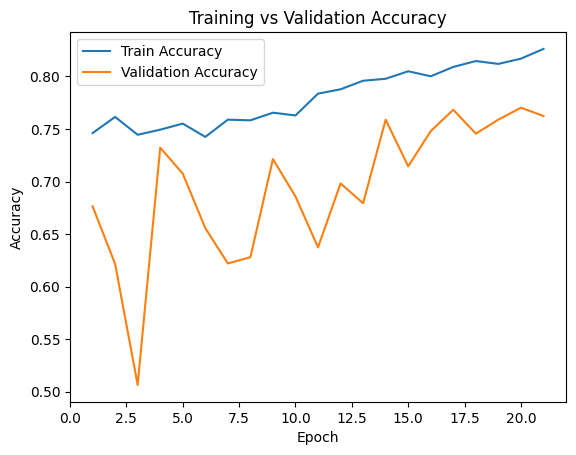

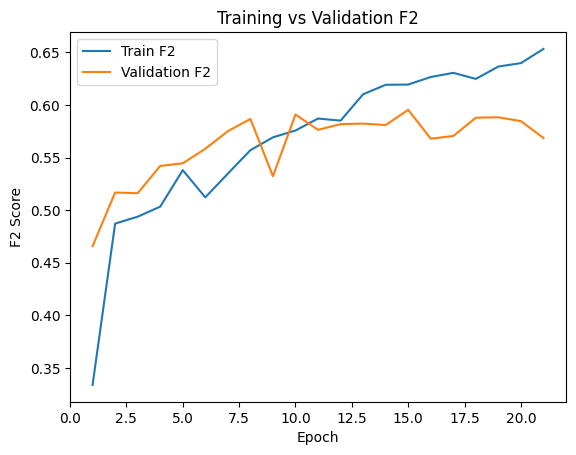

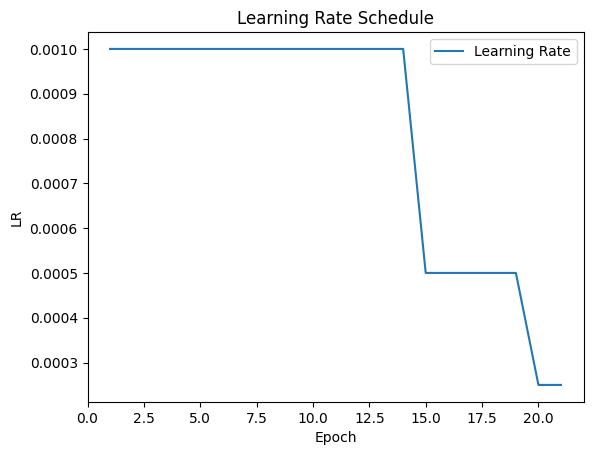

In [5]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, learning_rates, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('Learning Rate Schedule')
plt.legend()
plt.show()


### 6. Tune the threshold more carefully on validation data

This keeps `F2` as the main selection target, but only accepts thresholds that meet a minimum precision floor if possible.

In [6]:
model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.25, 0.81, 0.025)
precision_floor = 0.30

best_threshold = 0.5
best_f2 = -1
fallback_best_threshold = 0.5
fallback_best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    precision = precision_score(val_labels, preds, zero_division=0)
    recall = recall_score(val_labels, preds, zero_division=0)
    f2 = fbeta_score(val_labels, preds, beta=2, zero_division=0)
    bal_acc = balanced_accuracy_score(val_labels, preds)

    print(
        f"Threshold={threshold:.3f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"Balanced Acc={bal_acc:.4f}"
    )

    if f2 > fallback_best_f2:
        fallback_best_f2 = f2
        fallback_best_threshold = threshold

    if precision >= precision_floor and f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

if best_f2 < 0:
    best_threshold = fallback_best_threshold
    best_f2 = fallback_best_f2
    print(f"\nNo threshold met precision floor {precision_floor:.2f}; using best raw F2 threshold instead.")

print(f"\nSelected threshold on validation set: {best_threshold:.3f}")
print(f"Selected validation F2: {best_f2:.4f}")


Threshold=0.250 | F2=0.5779 | Precision=0.2254 | Recall=0.9492 | Balanced Acc=0.7593
Threshold=0.275 | F2=0.5798 | Precision=0.2278 | Recall=0.9449 | Balanced Acc=0.7610
Threshold=0.300 | F2=0.5844 | Precision=0.2313 | Recall=0.9449 | Balanced Acc=0.7652
Threshold=0.325 | F2=0.5904 | Precision=0.2372 | Recall=0.9407 | Balanced Acc=0.7707
Threshold=0.350 | F2=0.5881 | Precision=0.2386 | Recall=0.9280 | Balanced Acc=0.7685
Threshold=0.375 | F2=0.5954 | Precision=0.2447 | Recall=0.9280 | Balanced Acc=0.7749
Threshold=0.400 | F2=0.5913 | Precision=0.2460 | Recall=0.9110 | Balanced Acc=0.7712
Threshold=0.425 | F2=0.6012 | Precision=0.2547 | Recall=0.9110 | Balanced Acc=0.7796
Threshold=0.450 | F2=0.6005 | Precision=0.2595 | Recall=0.8941 | Balanced Acc=0.7787
Threshold=0.475 | F2=0.6029 | Precision=0.2663 | Recall=0.8814 | Balanced Acc=0.7804
Threshold=0.500 | F2=0.5954 | Precision=0.2702 | Recall=0.8517 | Balanced Acc=0.7740
Threshold=0.525 | F2=0.5803 | Precision=0.2742 | Recall=0.8051 | 

### 7. Evaluate best checkpoint on the test set

Confusion Matrix:
[[999 341]
 [ 49 122]]

              precision    recall  f1-score   support

           0     0.9532    0.7455    0.8367      1340
           1     0.2635    0.7135    0.3849       171

    accuracy                         0.7419      1511
   macro avg     0.6084    0.7295    0.6108      1511
weighted avg     0.8752    0.7419    0.7856      1511



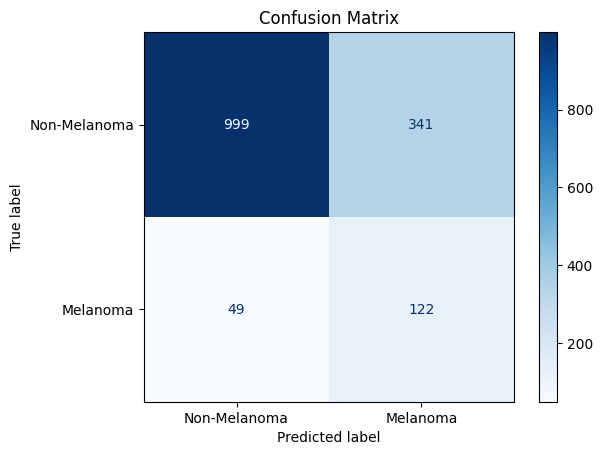

In [7]:
model = SimpleCNN().to(device)
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


- The improved weighted CNN uses a softer positive-class weight, validation F2 checkpointing, and more careful threshold selection to reduce the overly aggressive melanoma predictions seen in later CNN variants. 
- The model achieves 71.35% melanoma recall, 26.35% precision, and 74.19% overall accuracy, 
- indicating a better balance than the more recall-heavy focal-loss and augmented models. 
- The training curves suggest mild overfitting, as validation F2 peaks around epoch 15 and then plateaus while training performance continues to improve. 
- Overall, this notebook shows that reducing class-weighting strength and tuning the threshold more carefully can improve prediction balance, although the earlier weighted baseline in 02.cnn_baseline_weighted still remains the strongest overall model in terms of melanoma F1 and practical tradeoff.

- The model still shows mild overfitting because training performance continues to improve after validation F2 has already peaked. 
- This means the network is learning some patterns that help on the training set but do not generalize as well to validation data. 
- Although early stopping, regularization, and softer class weighting reduce the problem, they do not eliminate it entirely because the dataset remains difficult and imbalanced, and the model still has enough flexibility to fit some training-specific details.